In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_total = pd.read_csv("data/POBLACIÓ_TOTAL2262026_194109.csv", sep=";", encoding="utf-8-sig")
df_nationality = pd.read_csv("data/POBLACIÓ_PER_NACIONALITAT2262026_194534.csv", sep=";", encoding="utf-8-sig")
df_parish = pd.read_csv("data/POBLACIÓ_PER_PARRÒQUIA2262026_194602.csv", sep=";", encoding="utf-8-sig")

print("Total population shape:", df_total.shape)
print("Nationality shape:", df_nationality.shape)
print("Parish shape:", df_parish.shape)

Total population shape: (1, 19)
Nationality shape: (21, 18)
Parish shape: (8, 19)


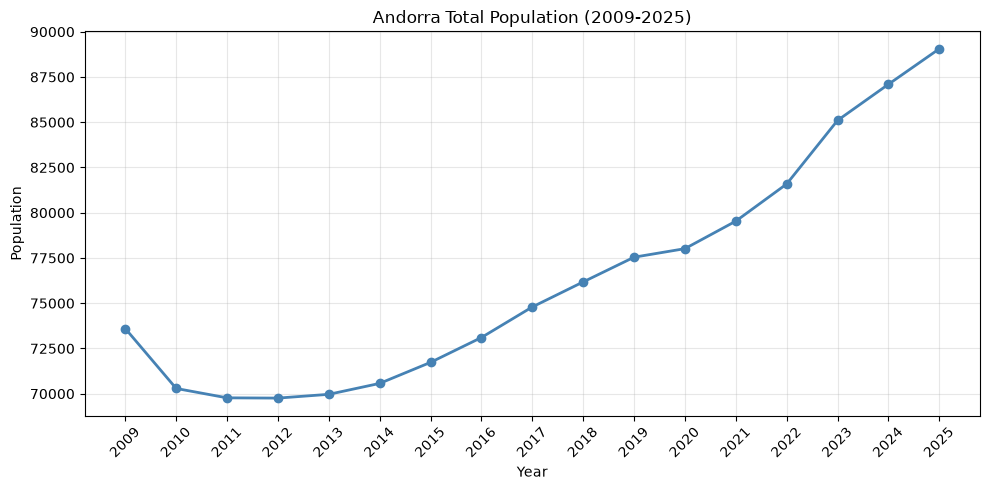

In [4]:
# Reshape total population data
years = [col for col in df_total.columns if col.isdigit()]
population = df_total[years].values[0]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, population, marker='o', color='steelblue', linewidth=2)
plt.title("Andorra Total Population (2009-2025)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 1. Total Population Evolution (2009-2025)

Andorra's population dropped significantly between 2009 and 2012, 
likely due to the global financial crisis. Recovery began in 2014 
and accelerated sharply after 2020, reaching 89,058 inhabitants in 2025.

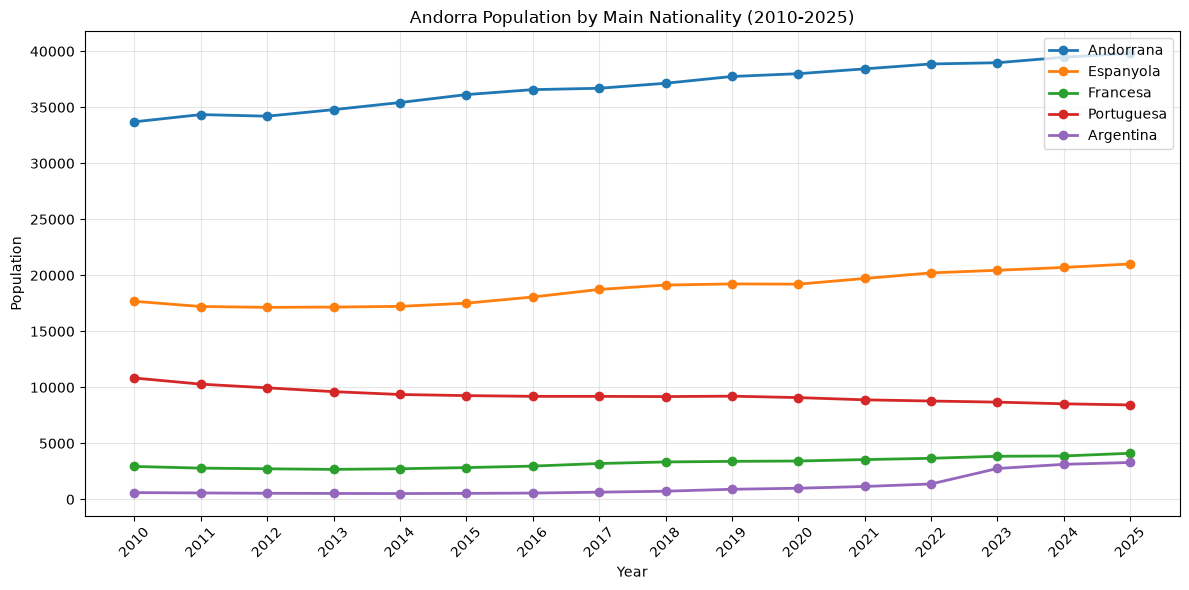

In [5]:
# Reshape nationality data
years_nat = [col for col in df_nationality.columns if col.isdigit()]

# Clean nationality names
df_nationality['name'] = df_nationality['Descripció'].str.replace('POBLACIÓ PER NACIONALITAT. ', '', regex=False).str.title()

# Plot main nationalities
main_nationalities = ['Andorrana', 'Espanyola', 'Portuguesa', 'Francesa', 'Argentina']

plt.figure(figsize=(12, 6))
for _, row in df_nationality.iterrows():
    if row['name'] in main_nationalities:
        values = row[years_nat].astype(float).values
        plt.plot(years_nat, values, marker='o', linewidth=2, label=row['name'])

plt.title("Andorra Population by Main Nationality (2010-2025)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Population by Main Nationality (2010-2025)

Portuguese nationals show a consistent decline (-22% since 2010), 
while Argentine nationals have grown nearly 6x since 2010, 
with a sharp acceleration after 2022. At current trends, 
Argentina will surpass Portugal as the third largest community before 2030.
Spanish nationals remain the second largest group and continue growing steadily.

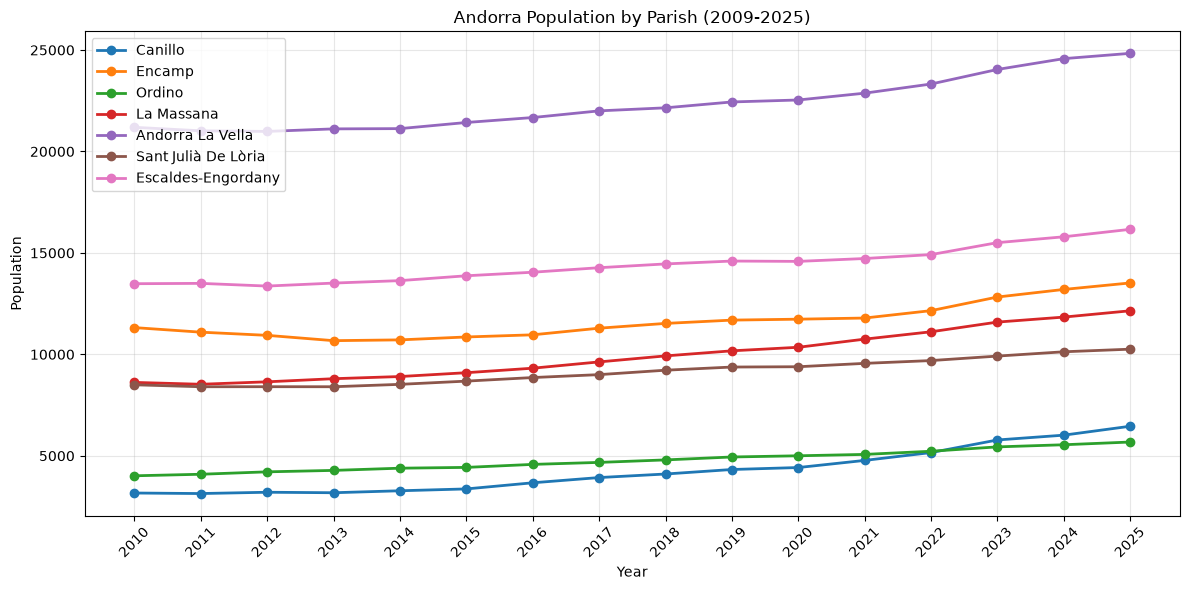

In [6]:
# Reshape parish data
years_par = [col for col in df_parish.columns if col.isdigit()]

# Clean parish names and remove TOTAL row
df_parish['name'] = df_parish['Descripció'].str.replace('POBLACIÓ PER PARRÒQUIA. ', '', regex=False).str.title()
df_parishes = df_parish[df_parish['name'] != 'Total'].copy()

# Plot
plt.figure(figsize=(12, 6))
for _, row in df_parishes.iterrows():
    values = row[years_par].astype(float).values
    plt.plot(years_par, values, marker='o', linewidth=2, label=row['name'])

plt.title("Andorra Population by Parish (2009-2025)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Population by Parish (2009-2025)

Andorra la Vella remains the most populated parish (24,836 in 2025), 
followed by Escaldes-Engordany (16,162). 
Canillo shows the highest relative growth (+103% since 2009), 
likely driven by tourism and real estate development around Grandvalira ski resort.
All parishes show consistent growth since 2014.

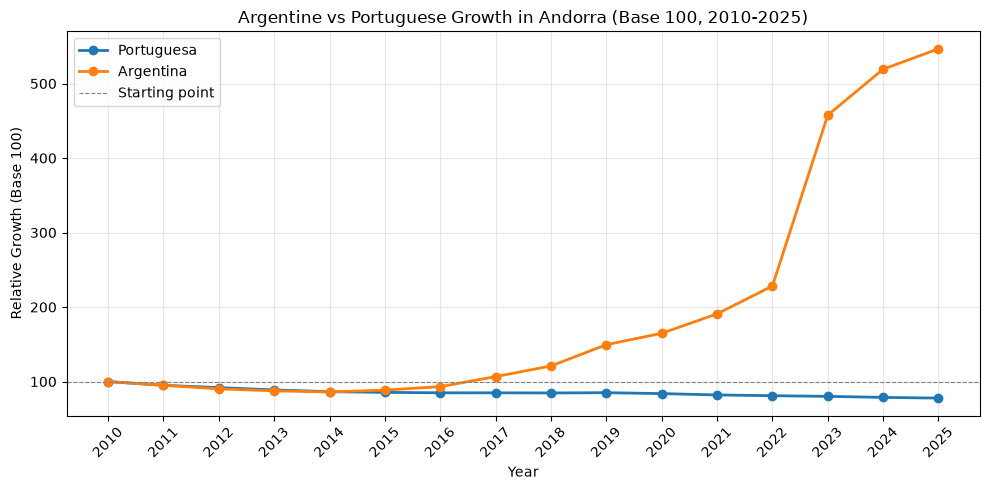

In [7]:
# Argentine vs Portuguese relative growth (base 100)
nat_of_interest = ['Portuguesa', 'Argentina']

plt.figure(figsize=(10, 5))
for _, row in df_nationality.iterrows():
    if row['name'] in nat_of_interest:
        values = row[years_nat].astype(float).values
        normalized = (values / values[0]) * 100
        plt.plot(years_nat, normalized, marker='o', linewidth=2, label=row['name'])

plt.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, label='Starting point')
plt.title("Argentine vs Portuguese Growth in Andorra (Base 100, 2010-2025)")
plt.xlabel("Year")
plt.ylabel("Relative Growth (Base 100)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Argentine vs Portuguese Relative Growth (Base 100)

The contrast is striking: while the Portuguese community has declined 
to 78% of its 2010 size, the Argentine community has grown to 547% 
of its 2010 level — a nearly 6x increase in 15 years.

The sharp acceleration after 2022 coincides with Argentina's severe 
economic crisis, suggesting this growth is largely crisis-driven emigration 
rather than organic migration patterns.

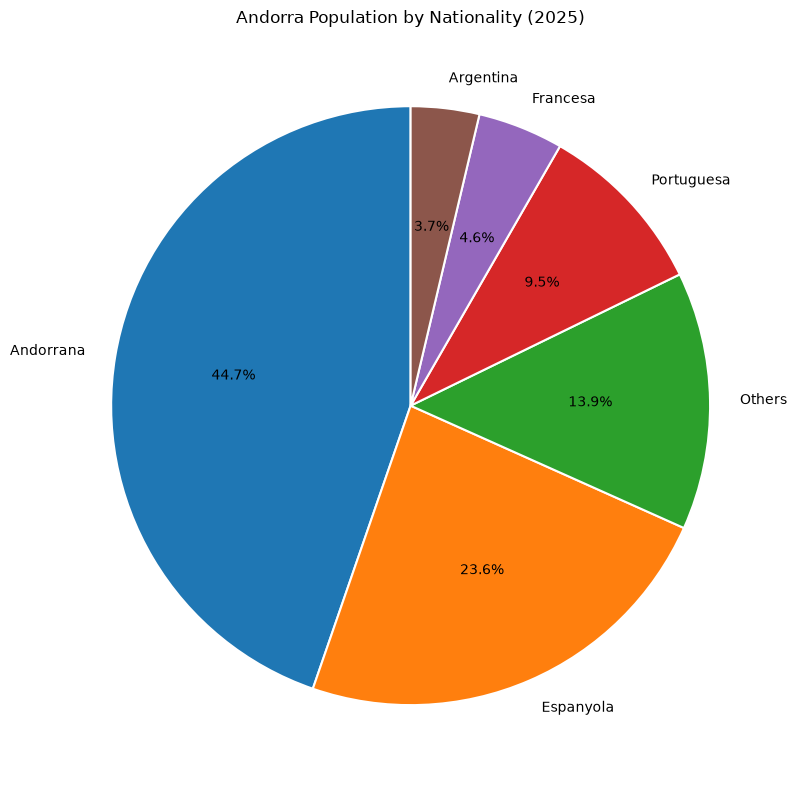

In [9]:
# Nationality distribution in 2025
latest_year = '2025'

# Get values for 2025
df_nat_2025 = df_nationality[['name', latest_year]].copy()
df_nat_2025[latest_year] = df_nat_2025[latest_year].astype(float)

# Group small nationalities into "Others"
threshold = 1000
df_nat_2025['group'] = df_nat_2025.apply(
    lambda row: 'Others' if row[latest_year] < threshold or row['name'] == 'Altres Nacionalitats' else row['name'], axis=1
)
df_grouped = df_nat_2025.groupby('group')[latest_year].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 8))
plt.pie(
    df_grouped.values,
    labels=df_grouped.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
plt.title("Andorra Population by Nationality (2025)")
plt.tight_layout()
plt.show()

## 5. Nationality Distribution in 2025

As of 2025, Andorran nationals represent only 44.7% of the population —
meaning more than half of Andorra's residents are foreign nationals.
Spanish nationals form the largest foreign community (23.6%),
followed by a growing "Others" category (13.9%) which includes 
nationalities not individually tracked, Portuguese nationals (9.5%),
French (4.6%), and Argentine nationals (3.7%) — 
the fastest growing community despite their still-small share.